# 01. EDA + Baseline ML v2

## 목적

`feature_table_v2.csv`를 기준으로 EDA와 기본 머신러닝 모델을 실행합니다.

| 섹션 | 내용 |
|---|---|
| EDA | 타겟 분포, 범주형/시간 피처, 상관관계, Star/Brand Power 확인 |
| Baseline ML | Linear / Ridge / Lasso / RandomForest 회귀, Logistic / RandomForest 분류 |
| 결과 저장 | 주요 그래프를 `images/eda_v2/`에 저장 |

> 다른 버전을 보고 싶으면 아래 환경 설정 셀의 `VERSION`만 바꾸면 됩니다.


---
## 0. 환경 설정


In [ ]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

warnings.filterwarnings("ignore")

# ─────────────────────────────
# 기본 설정
# ─────────────────────────────
VERSION = "v3"

DATA_PATH = Path(f"data/processed/feature_table_{VERSION}.csv")
BASE_IMAGE_DIR = Path(r"C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3")
BASE_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

run_idx = 1
while (BASE_IMAGE_DIR / f"{run_idx}회차").exists():
    run_idx += 1

IMAGE_DIR = BASE_IMAGE_DIR / f"{run_idx}회차"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
print(f"이미지 저장 폴더: {IMAGE_DIR}")

RANDOM_STATE = 42
TEST_YEAR = 2023  # open_year가 있으면 TEST_YEAR년부터 test set으로 사용


def save_fig(filename):
    """그래프 저장용 함수입니다."""
    save_path = IMAGE_DIR / filename
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"저장 완료: {save_path}")
    
# ─────────────────────────────
# 한글 폰트 설정
# ─────────────────────────────

def set_korean_font():
    system = platform.system()

    if system == "Windows":
        font_paths = [
            "C:/Windows/Fonts/malgun.ttf",
            "C:/Windows/Fonts/NanumGothic.ttf",
        ]
        candidates = ["Malgun Gothic", "NanumGothic"]
    elif system == "Darwin":
        font_paths = []
        candidates = ["AppleGothic", "NanumGothic"]
    else:
        font_paths = []
        candidates = ["NanumGothic", "Noto Sans CJK KR"]

    for font_path in font_paths:
        if os.path.exists(font_path):
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            return font_name

    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams["font.family"] = font
            plt.rcParams["axes.unicode_minus"] = False
            return font

    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
    return None

set_korean_font()



---
## 1. 데이터 로드 및 기본 확인


In [2]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# 시계열 분할(shuffle=False)을 위해 개봉일을 datetime으로 변환합니다.
# open_year는 EDA/요약 출력에서 함께 활용할 수 있도록 파생 컬럼으로 생성합니다.
if "open_date" in df.columns:
    df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")
    df["open_year"] = df["open_date"].dt.year

# Rebuild hit_class from hit_config.json.
config_path = Path("hit_config.json")
if config_path.exists() and "total_audience" in df.columns:
    with open(config_path, "r", encoding="utf-8") as f:
        hit_meta = json.load(f)

    hit_bins = [float("inf") if value == "inf" else value for value in hit_meta["HIT_BINS"]]
    hit_labels = hit_meta["HIT_LABELS"]
    df["hit_class"] = pd.cut(
        df["total_audience"],
        bins=hit_bins,
        labels=hit_labels,
        right=False,
        include_lowest=True,
    ).astype(int)

    print("hit_class rebuilt:")
    print(df["hit_class"].value_counts().sort_index())

# =========================================================
# 회귀 학습용 피처 고정
# - 아래 15개 피처만 사용해서 회귀 모델 학습
# - 누락 컬럼이 있으면 바로 확인할 수 있도록 에러 발생
# =========================================================
FEATURE_COLS = [
    'relative_search_share',
    'distributor_avg_audi',
    'trend_pre7_avg',
    'trend_pre7_max',
    'is_new_director',
    'genre_avg_audi',
    'is_new_lead',
    'is_new_producer',
    'runtime',
    'market_avg_audi_7d',
    'is_covid_period',
    'director_avg_audi',
    'producer_avg_audi',
    'holiday_nearby_count',
    'same_week_releases'
]

DROP_COLS = [
    col for col in df.columns
    if col not in FEATURE_COLS
]

missing_features = [col for col in FEATURE_COLS if col not in df.columns]
if missing_features:
    raise ValueError(f"데이터에 없는 피처가 있습니다: {missing_features}")

print("Regression features fixed to 15 columns:")
print(FEATURE_COLS)

print("\nFinal feature count:", len(FEATURE_COLS))

TIME_SPLIT = "open_date" in df.columns and df["open_date"].notna().all()

if not TIME_SPLIT:
    print("open_date column not available -> using random split")

print(f"Data file: {DATA_PATH}")
print(f"shape: {df.shape[0]} rows x {df.shape[1]} columns")

print("\nMissing values:")
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "None")

print("\ndtype summary:")
print(df.dtypes.value_counts().to_string())

df.head(3)


hit_class rebuilt:
hit_class
0    2153
1     336
Name: count, dtype: int64
Regression features fixed to 15 columns:
['relative_search_share', 'distributor_avg_audi', 'trend_pre7_avg', 'trend_pre7_max', 'is_new_director', 'genre_avg_audi', 'is_new_lead', 'is_new_producer', 'runtime', 'market_avg_audi_7d', 'is_covid_period', 'director_avg_audi', 'producer_avg_audi', 'holiday_nearby_count', 'same_week_releases']

Final feature count: 15
Data file: data\processed\feature_table_v3.csv
shape: 2489 rows x 45 columns

Missing values:
None

dtype summary:
int64             26
float64           13
str                4
datetime64[us]     1
int32              1


,movie_id,title,genre,nation,open_date,runtime,total_audience,total_sales,director_avg_audi,director_movie_count,...,is_new_producer,is_new_distributor,log_audience,genre_avg_audi,rating_15세관람가,rating_15세이상관람가,rating_전체관람가,rating_청소년관람불가,open_year,hit_class
0,20157042,셜록: 유령신부,범죄,영국,2016-01-02,114,1273087,9948563049,13.050499,0,...,1,0,14.056956,14.089391,0,0,0,0,2016,1
1,20158882,유스,드라마,이탈리아,2016-01-07,123,73034,566741900,10.375177,1,...,1,0,11.198694,13.390058,0,1,0,0,2016,0
2,20150024,짱구는 못말려 극장판: 나의 이사 이야기 선인장 대습격,애니메이션,일본,2016-01-07,103,179809,1307052400,11.232788,1,...,1,0,12.099656,12.927242,0,0,1,0,2016,0


---
## 2. 타겟 변수 분포

- `total_audience`: 실제 누적 관객수
- `log_audience`: 관객수를 로그 변환한 값
- `hit_class`: 흥행 구간 분류 타겟


저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\01_target_distribution_v3.png


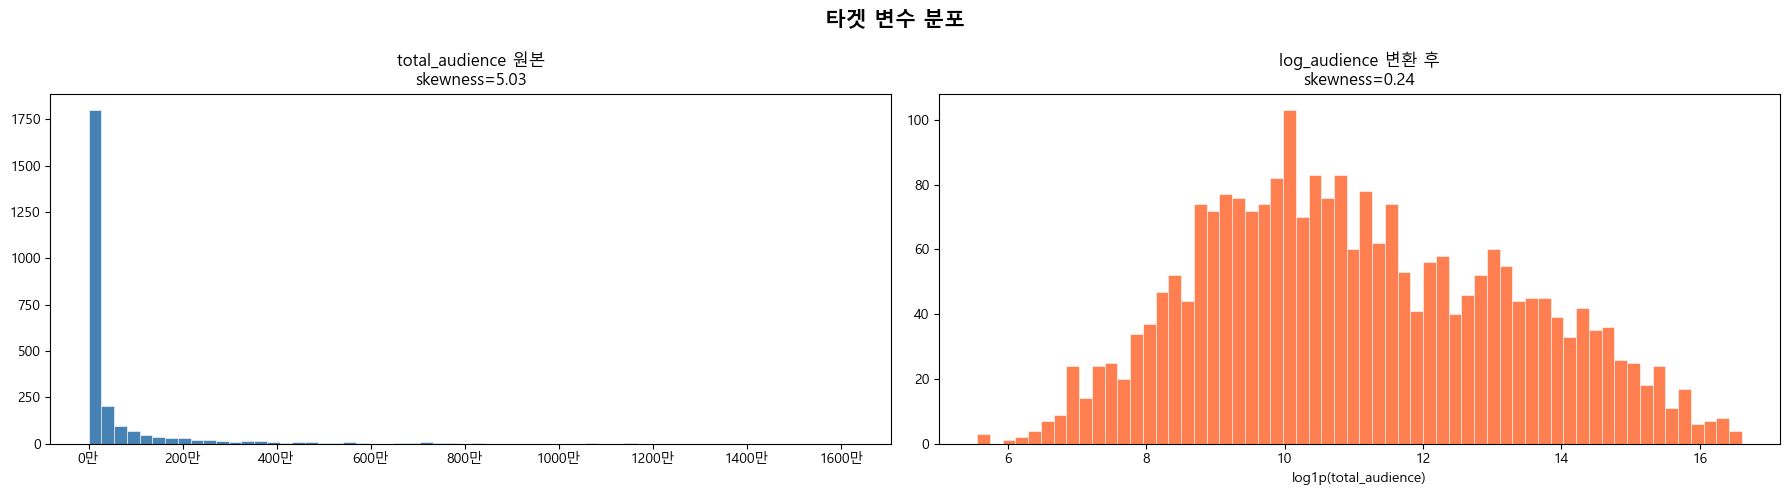


총 관객수 기술통계:
count         2,489
mean        565,742
std       1,513,966
min             259
25%          11,711
50%          49,307
75%         347,567
max      16,252,575
Name: total_audience, dtype: str


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("타겟 변수 분포", fontsize=15, fontweight="bold")

# 1) total_audience 원본
axes[0].hist(df["total_audience"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title(f'total_audience 원본\nskewness={df["total_audience"].skew():.2f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e4:.0f}만"))

# 2) log_audience
axes[1].hist(df["log_audience"], bins=60, color="coral", edgecolor="white", linewidth=0.4)
axes[1].set_title(f'log_audience 변환 후\nskewness={df["log_audience"].skew():.2f}')
axes[1].set_xlabel("log1p(total_audience)")

plt.tight_layout()
save_fig(f"01_target_distribution_{VERSION}.png")
plt.show()

print("\n총 관객수 기술통계:")
print(df["total_audience"].describe().apply(lambda x: f"{x:,.0f}"))


---
## 3. 범주형 피처와 평균 관객수

장르, 관람등급, 한국/외국 영화 여부에 따라 평균 관객수가 어떻게 달라지는지 확인합니다.


In [4]:
category_specs = [
    ("genre", "장르별 평균 관객수"),
    ("rating_encoded", "관람등급별 평균 관객수"),
    ("is_korean", "한국/외국 영화 평균 관객수"),
]
category_specs = [(col, title) for col, title in category_specs if col not in DROP_COLS and col in df.columns]

if category_specs:
    fig, axes = plt.subplots(1, len(category_specs), figsize=(6.5 * len(category_specs), 6))
    fig.suptitle("범주형 피처별 평균 관객수", fontsize=14, fontweight="bold")

    if len(category_specs) == 1:
        axes = [axes]

    for ax, (col, title) in zip(axes, category_specs):
        group = df.groupby(col)["total_audience"].mean().sort_values(ascending=True)

        if col == "rating_encoded":
            rating_label = {0: "전체", 1: "12세", 2: "15세", 3: "청불", 4: "제한"}
            group.index = [rating_label.get(i, str(i)) for i in group.index]

        elif col == "is_korean":
            korean_label = {0: "외국", 1: "한국"}
            group.index = [korean_label.get(i, str(i)) for i in group.index]

        bars = ax.barh(group.index.astype(str), group.values / 1e4, color="steelblue")
        ax.set_title(title)
        ax.set_xlabel("평균 관객수 (만 명)")

        for bar, val in zip(bars, group.values):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{val / 1e4:.1f}만",
                va="center",
                fontsize=8,
            )

    plt.tight_layout()
    save_fig(f"02_category_vs_audience_{VERSION}.png")
    plt.show()
else:
    print("시각화 가능한 범주형 피처가 없습니다.")


시각화 가능한 범주형 피처가 없습니다.


---
## 4. 시간/계절 피처 분석


In [5]:
time_plots = []

if "open_month" in df.columns and "open_month" not in DROP_COLS:
    time_plots.append("open_month")

if "open_day_of_week" in df.columns and "open_day_of_week" not in DROP_COLS:
    time_plots.append("open_day_of_week")

if time_plots:
    fig, axes = plt.subplots(1, len(time_plots), figsize=(8 * len(time_plots), 5))
    fig.suptitle("시간/계절 피처와 평균 관객수", fontsize=14, fontweight="bold")

    if len(time_plots) == 1:
        axes = [axes]

    for ax, col in zip(axes, time_plots):
        if col == "open_month":
            month_avg = df.groupby("open_month")["total_audience"].mean()
            month_label = ["1월", "2월", "3월", "4월", "5월", "6월", "7월", "8월", "9월", "10월", "11월", "12월"]
            month_colors = ["#f14e4e" if i in [1, 7, 8, 12] else "steelblue" for i in range(1, 13)]
            ax.bar(month_label, [month_avg.get(i, 0) / 1e4 for i in range(1, 13)], color=month_colors)
            ax.set_title("월별 평균 관객수 (빨간색=성수기)")
            ax.set_ylabel("평균 관객수 (만 명)")
            ax.tick_params(axis="x", rotation=45)

        elif col == "open_day_of_week":
            dow_avg = df.groupby("open_day_of_week")["total_audience"].mean()
            dow_label = ["월", "화", "수", "목", "금", "토", "일"]
            dow_colors = ["#f14e4e" if i >= 4 else "steelblue" for i in range(7)]
            ax.bar(dow_label, [dow_avg.get(i, 0) / 1e4 for i in range(7)], color=dow_colors)
            ax.set_title("개봉 요일별 평균 관객수 (빨간색=금/토/일)")
            ax.set_ylabel("평균 관객수 (만 명)")

    plt.tight_layout()
    save_fig(f"03_time_season_vs_audience_{VERSION}.png")
    plt.show()
else:
    print("시간 피처가 DROP_COLS에 포함되어 시간/요일 그래프는 건너뜁니다.")

if "is_holiday_release" in df.columns and "is_holiday_release" not in DROP_COLS:
    print("공휴일 개봉 여부별 평균 관객수:")
    holiday_summary = (
        df.groupby("is_holiday_release")["total_audience"]
        .agg(["mean", "count"])
        .rename(index={0: "비공휴일", 1: "공휴일"})
    )
    print(holiday_summary.map(lambda x: f"{x:,.0f}"))


시간 피처가 DROP_COLS에 포함되어 시간/요일 그래프는 건너뜁니다.


---
## 5. 실제 관람 요일별 총 관객수

`weekday_0_ratio`~`weekday_4_ratio`, `weekend_ratio`를 이용해 실제 관람이 어느 요일에 몰렸는지 추정합니다.

> 주말은 토/일을 구분하는 컬럼이 없어서 반반으로 나누어 추정했습니다.


In [6]:
weekday_ratio_cols = [f"weekday_{day}_ratio" for day in range(5)]
required_cols = weekday_ratio_cols + ["weekend_ratio", "total_audience"]

if all(col in df.columns for col in required_cols):
    day_total = []

    # 월~금 관객수
    for col in weekday_ratio_cols:
        total = (df[col] * df["total_audience"]).sum()
        day_total.append(total / 1e6)  # 백만 명 단위

    # 토/일 관객수는 weekend_ratio를 반반으로 나누어 추정
    weekend_total = (df["weekend_ratio"] * df["total_audience"]).sum() / 1e6
    day_total.extend([weekend_total / 2, weekend_total / 2])

    dow_labels = ["월", "화", "수", "목", "금", "토", "일"]
    colors = ["steelblue", "steelblue", "steelblue", "steelblue", "#f14e4e", "#f14e4e", "#f14e4e"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(dow_labels, day_total, color=colors)

    ax.set_title("실제 요일별 총 관람객 수")
    ax.set_ylabel("총 관객수 (백만 명)")

    for bar, val in zip(bars, day_total):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:,.1f}M",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    save_fig(f"04_actual_day_audience_{VERSION}.png")
    plt.show()

else:
    print("요일별 관람 비율 컬럼이 부족해서 이 그래프는 건너뜁니다.")


요일별 관람 비율 컬럼이 부족해서 이 그래프는 건너뜁니다.


---
## 6. Star Power / Brand Power 분포

감독, 배우, 배급사, 제작사 관련 파워 피처의 분포와 0값 비율을 확인합니다.


저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\05_star_brand_power_dist_v3.png


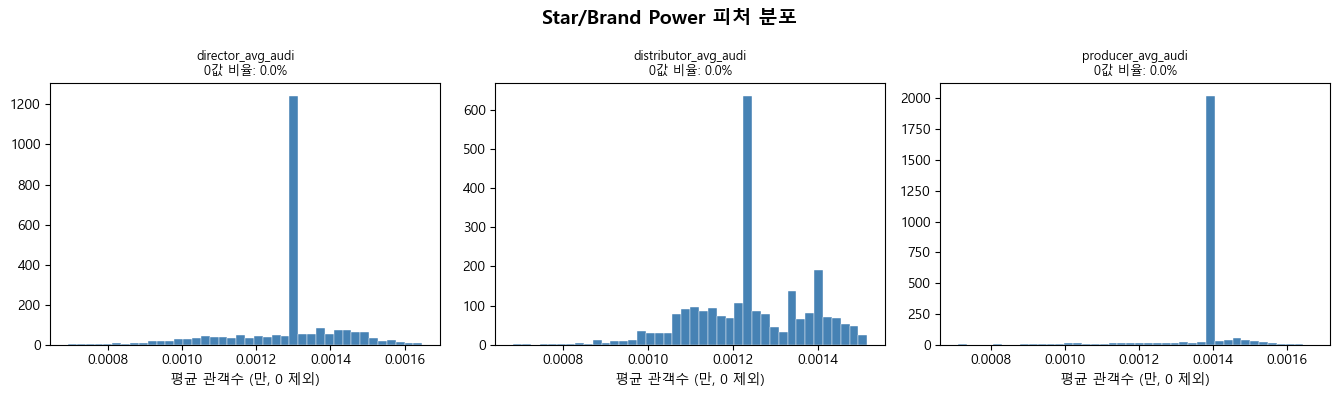


Star/Brand Power 0값 비율 요약:
  ✅ director_avg_audi: 0.0%
  ✅ distributor_avg_audi: 0.0%
  ✅ producer_avg_audi: 0.0%


In [7]:
power_cols = [
    "director_avg_audi",
    "lead_actor_avg_audi",
    "cast_max_star_power",
    "distributor_avg_audi",
    "producer_avg_audi",
]

power_cols = [col for col in power_cols if col in df.columns and col not in DROP_COLS]

if len(power_cols) > 0:
    fig, axes = plt.subplots(1, len(power_cols), figsize=(4.5 * len(power_cols), 4))
    fig.suptitle("Star/Brand Power 피처 분포", fontsize=14, fontweight="bold")

    if len(power_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, power_cols):
        nonzero = df.loc[df[col] > 0, col]
        zero_pct = (df[col] == 0).mean() * 100

        ax.hist(nonzero / 1e4, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
        ax.set_title(f"{col}\n0값 비율: {zero_pct:.1f}%", fontsize=9)
        ax.set_xlabel("평균 관객수 (만, 0 제외)")

    plt.tight_layout()
    save_fig(f"05_star_brand_power_dist_{VERSION}.png")
    plt.show()

    print("\nStar/Brand Power 0값 비율 요약:")
    for col in power_cols:
        zero_pct = (df[col] == 0).mean()
        flag = "⚠️" if zero_pct > 0.7 else "✅"
        print(f"  {flag} {col}: {zero_pct:.1%}")

else:
    print("Star/Brand Power 컬럼이 없어서 이 분석은 건너뜁니다.")


---
## 7. 피처-타겟 상관관계

숫자형 피처끼리의 상관관계와 `log_audience`와의 상관계수를 확인합니다.


The correlation heatmaps now use the same 15 `FEATURE_COLS` used by the regression models. All 15 selected features are numeric, so the axes show `log_audience` plus those 15 regression inputs.

저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\06_correlation_heatmap_v3.png


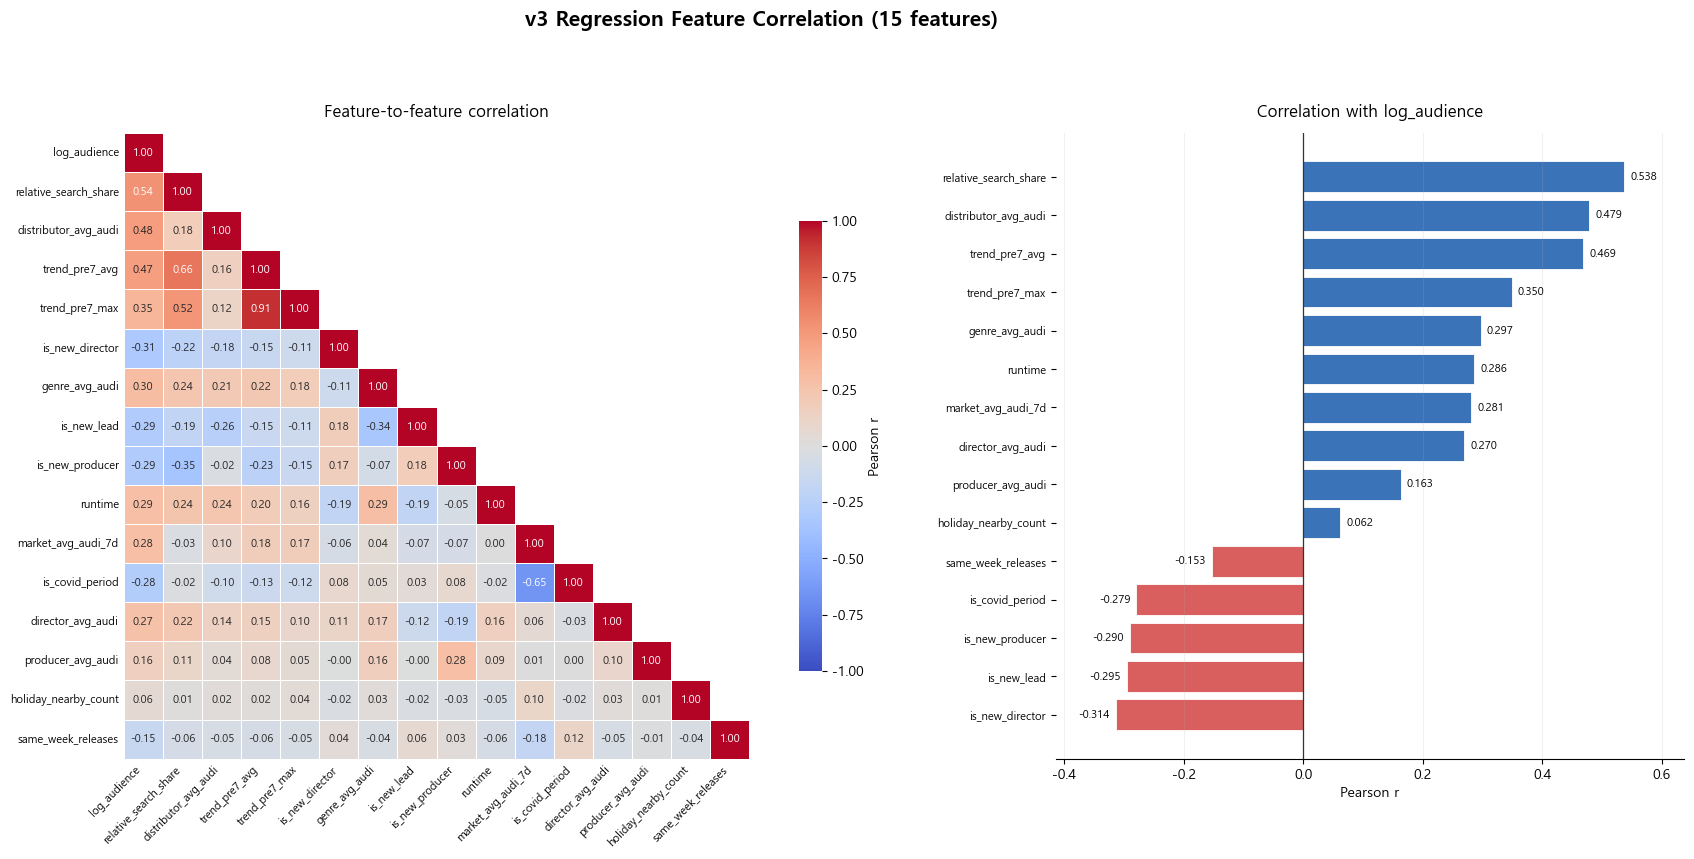


Heatmap regression feature count: 15
['relative_search_share', 'distributor_avg_audi', 'trend_pre7_avg', 'trend_pre7_max', 'is_new_director', 'genre_avg_audi', 'is_new_lead', 'is_new_producer', 'runtime', 'market_avg_audi_7d', 'is_covid_period', 'director_avg_audi', 'producer_avg_audi', 'holiday_nearby_count', 'same_week_releases']

Top 5 absolute correlations with log_audience:
relative_search_share    0.5378
distributor_avg_audi     0.4789
trend_pre7_avg           0.4689
trend_pre7_max           0.3496
is_new_director          0.3139
Name: log_audience, dtype: str


In [8]:
numeric_feature_cols = [
    col for col in FEATURE_COLS
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

corr_cols = ["log_audience"] + numeric_feature_cols
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 8.5),
    gridspec_kw={"width_ratios": [1.35, 0.85]},
)
fig.suptitle(
    f"{VERSION} Regression Feature Correlation (15 features)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

sns.heatmap(
    corr,
    mask=mask,
    ax=axes[0],
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.72, "label": "Pearson r"},
)
axes[0].set_title("Feature-to-feature correlation", fontsize=12, pad=12)
axes[0].set_xticklabels(corr.columns, rotation=45, fontsize=8, ha="right")
axes[0].set_yticklabels(corr.index, rotation=0, fontsize=8)
axes[0].tick_params(axis="both", length=0)

corr_target = corr["log_audience"].drop("log_audience").sort_values()
colors = ["#d95f5f" if value < 0 else "#3b73b9" for value in corr_target.values]

axes[1].barh(corr_target.index, corr_target.values, color=colors, edgecolor="white", linewidth=0.6)
axes[1].axvline(0, color="#333333", linewidth=0.9)
axes[1].set_title("Correlation with log_audience", fontsize=12, pad=12)
axes[1].set_xlabel("Pearson r")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines[["top", "right", "left"]].set_visible(False)

x_min = min(-0.05, corr_target.min() - 0.10)
x_max = max(0.05, corr_target.max() + 0.10)
axes[1].set_xlim(x_min, x_max)

for i, (feature, value) in enumerate(corr_target.items()):
    axes[1].text(
        value + (0.01 if value >= 0 else -0.01),
        i,
        f"{value:.3f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8,
    )

plt.tight_layout(pad=2.0)
save_fig(f"06_correlation_heatmap_{VERSION}.png")
plt.show()

print("\nHeatmap regression feature count:", len(numeric_feature_cols))
print(numeric_feature_cols)
print("\nTop 5 absolute correlations with log_audience:")
print(corr_target.abs().sort_values(ascending=False).head(5).apply(lambda x: f"{x:.4f}"))


---
## 8. Train / Test 분할

- `open_date` 기준으로 정렬한 뒤 `shuffle=False` 시계열 8:2 분할을 사용합니다.
- `open_date`가 없거나 결측이면 랜덤 8:2 분할을 fallback으로 사용합니다.


In [9]:
MODEL_DF = df.dropna(subset=["log_audience", "total_audience"]).copy()

X = MODEL_DF[FEATURE_COLS].copy()
yr = MODEL_DF["log_audience"].copy()

NUM_COLS = [
    col for col in X.columns
    if pd.api.types.is_numeric_dtype(X[col])
]
CAT_COLS = [col for col in X.columns if col not in NUM_COLS]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ]
)

if TIME_SPLIT:
    # 실제 운영 시나리오처럼 과거 개봉작으로 미래 개봉작을 예측하도록 open_date 순서로 정렬합니다.
    sorted_idx = MODEL_DF.sort_values("open_date").index
    X_sorted = X.loc[sorted_idx]
    yr_sorted = yr.loc[sorted_idx]

    # shuffle=False로 앞 80%는 train, 뒤 20%는 test로 분할합니다.
    X_train_reg, X_test_reg, yr_train, yr_test = train_test_split(
        X_sorted,
        yr_sorted,
        test_size=0.2,
        shuffle=False,
    )
    print(f"regression time split (open_date, shuffle=False): train={len(X_train_reg)} / test={len(X_test_reg)}")

if not TIME_SPLIT:
    X_train_reg, X_test_reg, yr_train, yr_test = train_test_split(
        X,
        yr,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    print(f"regression random split: train={len(X_train_reg)} / test={len(X_test_reg)}")

print(f"used features: {len(FEATURE_COLS)}")
print(f"numeric features: {len(NUM_COLS)}")
print(f"categorical features: {len(CAT_COLS)}")


regression random split: train=1991 / test=498
used features: 15
numeric features: 15
categorical features: 0


---
## 9. 회귀 모델 학습

타겟은 `log_audience`입니다.  
예측값은 `np.expm1()`로 실제 관객수 단위로 복원합니다.


In [10]:
# =========================================================
# Regression model tuning
# - Use only the original notebook models.
# - Ridge/Lasso are tuned with CV.
# - RandomForest uses the best parameters found from the previous tuning run.
# =========================================================

R2_KEY = "R\u00b2"
RMSE_REAL_KEY = "RMSE(\uc2e4\uc81c)"
MAE_REAL_KEY = "MAE(\uc2e4\uc81c)"
MODEL_COL = "\ubaa8\ub378"
MAE_REAL_10K_COL = "MAE(\uc2e4\uc81c\uad00\uac1d\uc218_\ub9cc\uba85)"

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = "neg_root_mean_squared_error"

search_specs = {
    "Linear Regression": {
        "estimator": Pipeline(
            steps=[
                ("pre", preprocessor),
                ("model", LinearRegression()),
            ]
        ),
        "search": "none",
        "params": {},
    },
    "Ridge": {
        "estimator": Pipeline(
            steps=[
                ("pre", preprocessor),
                ("model", Ridge(random_state=RANDOM_STATE)),
            ]
        ),
        "search": "grid",
        "params": {
            "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        },
    },
    "Lasso": {
        "estimator": Pipeline(
            steps=[
                ("pre", preprocessor),
                ("model", Lasso(random_state=RANDOM_STATE, max_iter=20000)),
            ]
        ),
        "search": "grid",
        "params": {
            "model__alpha": [0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
        },
    },
    "RandomForest": {
        "estimator": Pipeline(
            steps=[
                ("pre", preprocessor),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=500,
                        max_depth=16,
                        min_samples_split=5,
                        min_samples_leaf=2,
                        max_features=0.8,
                        bootstrap=True,
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "search": "none",
        "params": {
            "model__n_estimators": 500,
            "model__max_depth": 16,
            "model__min_samples_split": 5,
            "model__min_samples_leaf": 2,
            "model__max_features": 0.8,
            "model__bootstrap": True,
        },
    },
}


def evaluate_regression_model(pipe):
    pred_log = pipe.predict(X_test_reg)

    rmse_log = np.sqrt(mean_squared_error(yr_test, pred_log))
    mae_log = mean_absolute_error(yr_test, pred_log)
    r2 = r2_score(yr_test, pred_log)

    pred_log_clipped = np.clip(pred_log, yr_train.min(), yr_train.max())
    pred_real = np.expm1(pred_log_clipped)
    true_real = np.expm1(yr_test)

    rmse_real = np.sqrt(mean_squared_error(true_real, pred_real))
    mae_real = mean_absolute_error(true_real, pred_real)

    return {
        "pipe": pipe,
        "RMSE(log)": rmse_log,
        "MAE(log)": mae_log,
        R2_KEY: r2,
        RMSE_REAL_KEY: rmse_real,
        MAE_REAL_KEY: mae_real,
    }


reg_results = {}
tuning_rows = []

for name, spec in search_specs.items():
    print(f"\n[{name}] tuning...")

    if spec["search"] == "none":
        best_pipe = spec["estimator"]
        best_pipe.fit(X_train_reg, yr_train)
        best_params = spec["params"]
        best_cv_rmse = np.nan
    elif spec["search"] == "grid":
        search = GridSearchCV(
            estimator=spec["estimator"],
            param_grid=spec["params"],
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        search.fit(X_train_reg, yr_train)
        best_pipe = search.best_estimator_
        best_params = search.best_params_
        best_cv_rmse = -search.best_score_
    elif spec["search"] == "random":
        search = RandomizedSearchCV(
            estimator=spec["estimator"],
            param_distributions=spec["params"],
            n_iter=spec.get("n_iter", 30),
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            refit=True,
            random_state=RANDOM_STATE,
            verbose=0,
        )
        search.fit(X_train_reg, yr_train)
        best_pipe = search.best_estimator_
        best_params = search.best_params_
        best_cv_rmse = -search.best_score_
    else:
        raise ValueError(f"Unknown search type: {spec['search']}")

    result = evaluate_regression_model(best_pipe)
    reg_results[name] = result

    tuning_rows.append(
        {
            "model": name,
            "CV_RMSE(log)": best_cv_rmse,
            "R2": result[R2_KEY],
            "RMSE(log)": result["RMSE(log)"],
            "MAE(log)": result["MAE(log)"],
            "MAE(real_10k)": result[MAE_REAL_KEY] / 1e4,
            "best_params": best_params,
        }
    )

    print(f"  best CV RMSE(log): {best_cv_rmse:.4f}" if not np.isnan(best_cv_rmse) else "  no CV search")
    print(f"  best params: {best_params}")
    print(
        f"  holdout R2={result[R2_KEY]:.4f} / "
        f"RMSE(log)={result['RMSE(log)']:.4f} / "
        f"MAE(real)={result[MAE_REAL_KEY]/1e4:.1f} man"
    )

df_tuning_result = pd.DataFrame(tuning_rows).sort_values("RMSE(log)")
df_reg_result = pd.DataFrame(
    [
        {
            MODEL_COL: row["model"],
            R2_KEY: row["R2"],
            "RMSE(log)": row["RMSE(log)"],
            MAE_REAL_10K_COL: row["MAE(real_10k)"],
        }
        for row in tuning_rows
    ]
).sort_values(R2_KEY, ascending=False)

best_model_name = df_tuning_result.iloc[0]["model"]
best_model = reg_results[best_model_name]["pipe"]
best_params = df_tuning_result.iloc[0]["best_params"]

print("\nBest model by holdout RMSE(log):", best_model_name)
print("Best params:")
print(best_params)

df_tuning_result



[Linear Regression] tuning...
  no CV search
  best params: {}
  holdout R2=0.5233 / RMSE(log)=1.4070 / MAE(real)=41.3 man

[Ridge] tuning...
  best CV RMSE(log): 1.4428
  best params: {'model__alpha': 10.0}
  holdout R2=0.5233 / RMSE(log)=1.4070 / MAE(real)=41.2 man

[Lasso] tuning...
  best CV RMSE(log): 1.4431
  best params: {'model__alpha': 0.0001}
  holdout R2=0.5233 / RMSE(log)=1.4070 / MAE(real)=41.3 man

[RandomForest] tuning...
  no CV search
  best params: {'model__n_estimators': 500, 'model__max_depth': 16, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__bootstrap': True}
  holdout R2=0.5477 / RMSE(log)=1.3705 / MAE(real)=31.3 man

Best model by holdout RMSE(log): RandomForest
Best params:
{'model__n_estimators': 500, 'model__max_depth': 16, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__bootstrap': True}


,model,CV_RMSE(log),R2,RMSE(log),MAE(log),MAE(real_10k),best_params
3,RandomForest,NaN,0.547733,1.370505,1.052908,31.331765,"{'model__n_estimators': 500, 'model__max_depth..."
2,Lasso,1.443063,0.523343,1.406975,1.118233,41.306030,{'model__alpha': 0.0001}
0,Linear Regression,NaN,0.523337,1.406984,1.118239,41.309138,{}
1,Ridge,1.442767,0.523306,1.407030,1.118246,41.156745,{'model__alpha': 10.0}


---
## 9-1. RandomForest 모델 파일 저장


In [11]:
import pickle

# 학습이 끝난 RandomForest 파이프라인을 가져옵니다.
# pipe 안에는 전처리기(preprocessor)와 RandomForestRegressor가 함께 들어 있습니다.
rf_pipe = reg_results["RandomForest"]["pipe"]

# 다른 ML/DL/앙상블 모델과 함께 관리하기 위해 SKN30-2nd-4Team/ml/models 폴더에 저장합니다.
# 이 노트북은 ml 폴더 기준으로 실행되므로 상대 경로는 models 입니다.
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 파일명에는 버전과 검증 방식(time split)을 포함해 나중에 구분하기 쉽게 합니다.
rf_model_path = MODEL_DIR / f"{VERSION}_timesplit_randomforest.pkl"

# pickle로 sklearn Pipeline 전체를 저장하면, 로드 후 바로 predict에 사용할 수 있습니다.
with open(rf_model_path, "wb") as f:
    pickle.dump(rf_pipe, f)

print(f"RandomForest 모델 저장 완료: {rf_model_path}")


RandomForest 모델 저장 완료: models\v3_timesplit_randomforest.pkl


---
## 9-2. 저장된 RandomForest 모델 로드 및 성능 확인


In [16]:
# 저장된 pkl 파일을 다시 불러와서 정상적으로 예측되는지 확인합니다.
with open(rf_model_path, "rb") as f:
    loaded_rf_pipe = pickle.load(f)

# 테스트셋에 대해 log_audience 예측값을 생성합니다.
pred_log = loaded_rf_pipe.predict(X_test_reg)

# log 스케일 기준 성능 지표를 계산합니다.
rmse_log = np.sqrt(mean_squared_error(yr_test, pred_log))
mae_log = mean_absolute_error(yr_test, pred_log)
r2 = r2_score(yr_test, pred_log)

# 실제 관객수 단위로 복원한 뒤 MAE를 계산합니다.
# 학습 타겟 범위를 벗어난 예측값은 과도한 exp 변환을 막기 위해 train 범위로 clip합니다.
pred_log_clipped = np.clip(pred_log, yr_train.min(), yr_train.max())
pred_real = np.expm1(pred_log_clipped)
true_real = np.expm1(yr_test)
mae_real = mean_absolute_error(true_real, pred_real)

print("Loaded model:", type(loaded_rf_pipe))
print("Pipeline steps:", list(loaded_rf_pipe.named_steps.keys()))
print(f"R²: {r2:.4f}")
print(f"RMSE(log): {rmse_log:.4f}")
print(f"MAE(log): {mae_log:.4f}")
print(f"MAE(실제 관객수): {mae_real:,.0f}명")
print(f"MAE(만 명): {mae_real / 1e4:.1f}만 명")


Loaded model: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['pre', 'model']
R²: 0.5477
RMSE(log): 1.3705
MAE(log): 1.0529
MAE(실제 관객수): 313,318명
MAE(만 명): 31.3만 명


---
## 10. 회귀 결과 시각화


저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\07_regression_scatter_v3.png


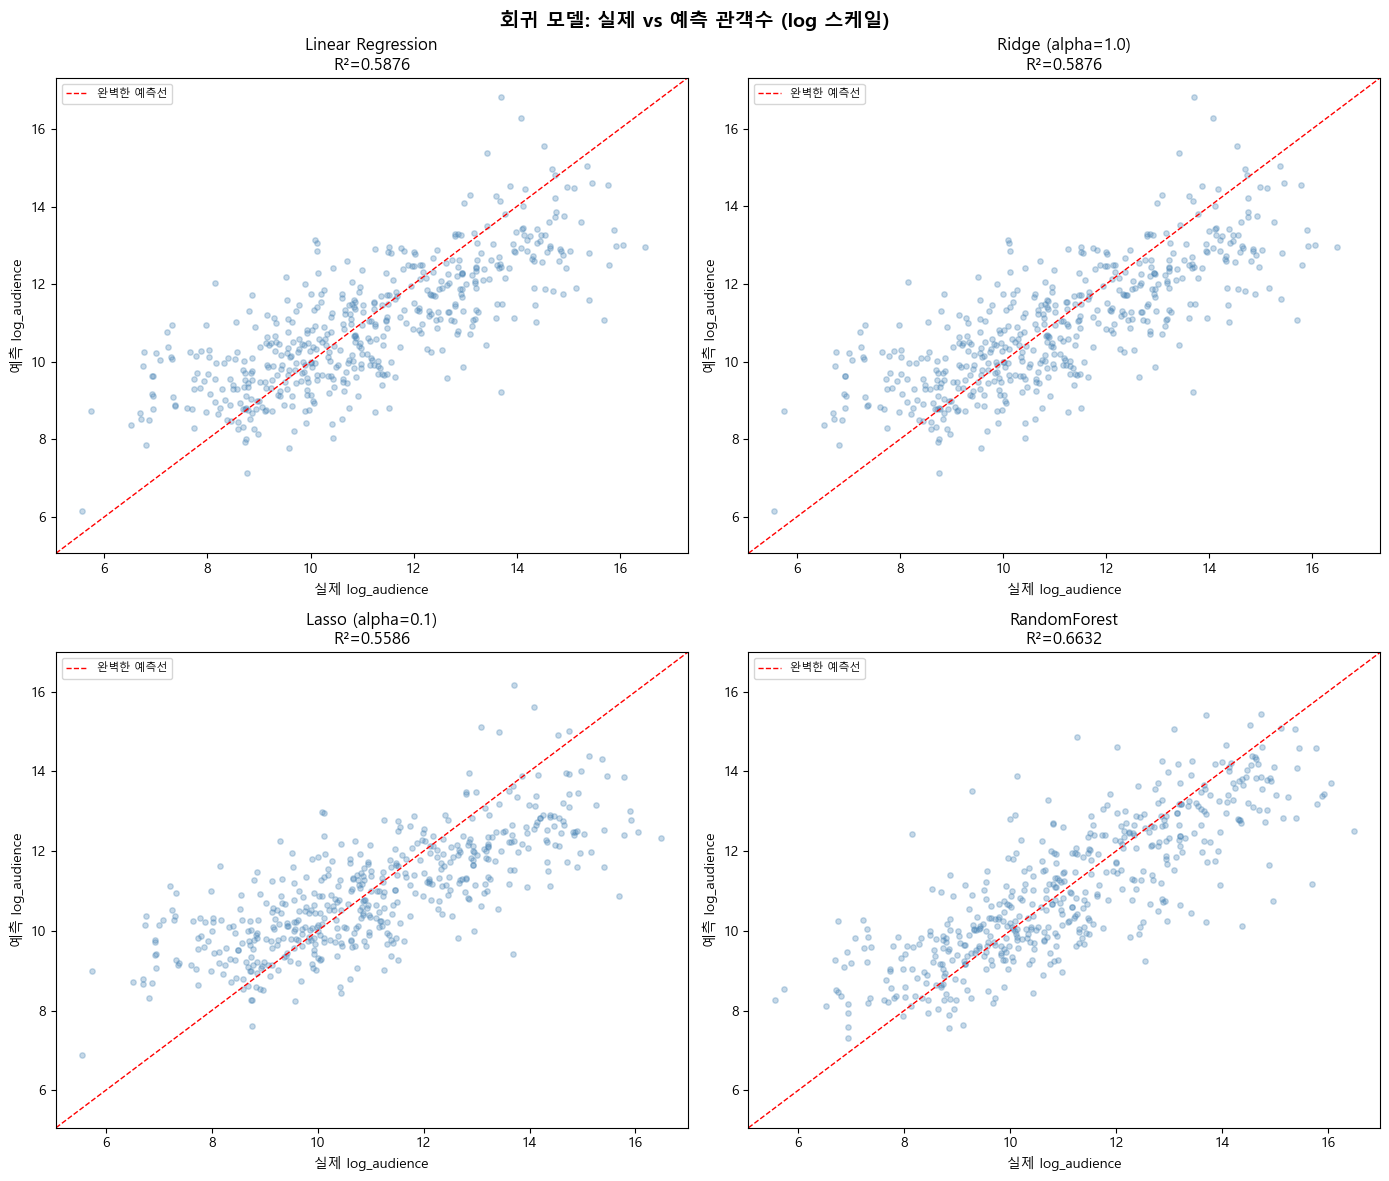

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("회귀 모델: 실제 vs 예측 관객수 (log 스케일)", fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, (name, result) in zip(axes, reg_results.items()):
    pred = result["pipe"].predict(X_test_reg)

    ax.scatter(yr_test, pred, alpha=0.3, s=15, color="steelblue")

    lim = [
        min(yr_test.min(), pred.min()) - 0.5,
        max(yr_test.max(), pred.max()) + 0.5,
    ]

    ax.plot(lim, lim, "r--", linewidth=1, label="완벽한 예측선")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("실제 log_audience")
    ax.set_ylabel("예측 log_audience")
    ax.set_title(f'{name}\nR²={result["R²"]:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig(f"07_regression_scatter_{VERSION}.png")
plt.show()


---
## 11. RandomForest 피처 중요도


저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\08_rf_feature_importance_reg_v3.png


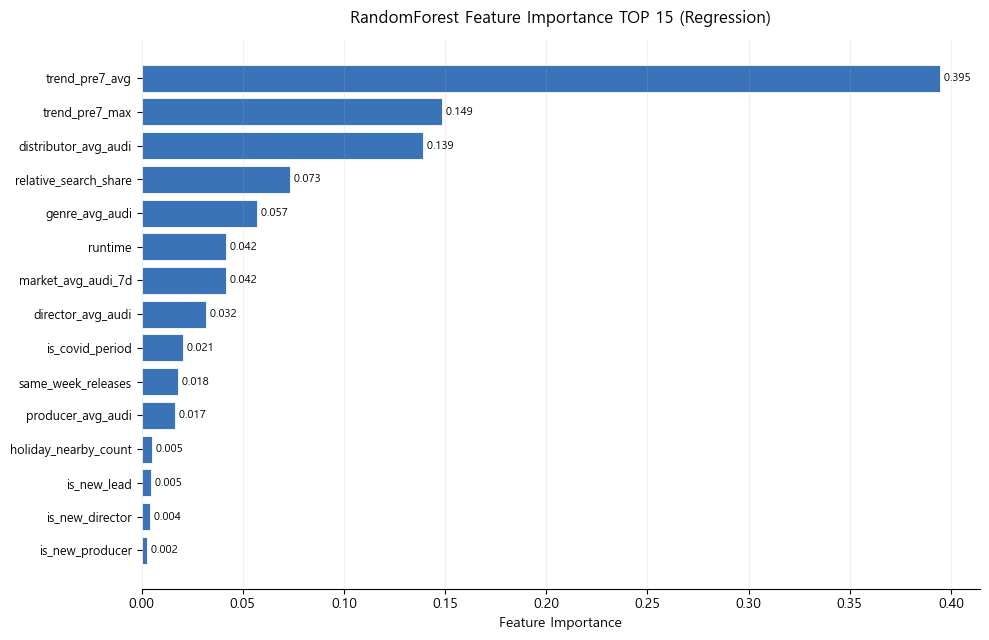

,feature,importance
2,trend_pre7_avg,0.394616
3,trend_pre7_max,0.148683
1,distributor_avg_audi,0.139048
0,relative_search_share,0.073252
5,genre_avg_audi,0.057165
8,runtime,0.041951
9,market_avg_audi_7d,0.041513
11,director_avg_audi,0.031930
10,is_covid_period,0.020600
14,same_week_releases,0.018062


In [12]:
rf_pipe = reg_results["RandomForest"]["pipe"]

ohe = rf_pipe["pre"].named_transformers_["cat"]
ohe_cols = ohe.get_feature_names_out(CAT_COLS).tolist() if len(CAT_COLS) > 0 else []

all_feature_names = NUM_COLS + ohe_cols
importances = rf_pipe["model"].feature_importances_

top_n = min(15, len(all_feature_names))
df_imp = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=True)
    .tail(top_n)
)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(df_imp["feature"], df_imp["importance"], color="#3b73b9", edgecolor="white", linewidth=0.6)
ax.set_title(f"RandomForest Feature Importance TOP {top_n} (Regression)", fontsize=12, pad=12)
ax.set_xlabel("Feature Importance")
ax.grid(axis="x", alpha=0.18)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

for i, value in enumerate(df_imp["importance"]):
    ax.text(value, i, f" {value:.3f}", va="center", fontsize=8)

plt.tight_layout()
save_fig(f"08_rf_feature_importance_reg_{VERSION}.png")
plt.show()

df_imp.sort_values("importance", ascending=False)


---
## 12. 모델 성능 비교 그래프


저장 완료: C:\Users\playdata2\Desktop\2nd_proj\SKN30-2nd-4Team\ml\images\eda_v3\7회차\10_regression_model_comparison_v3.png


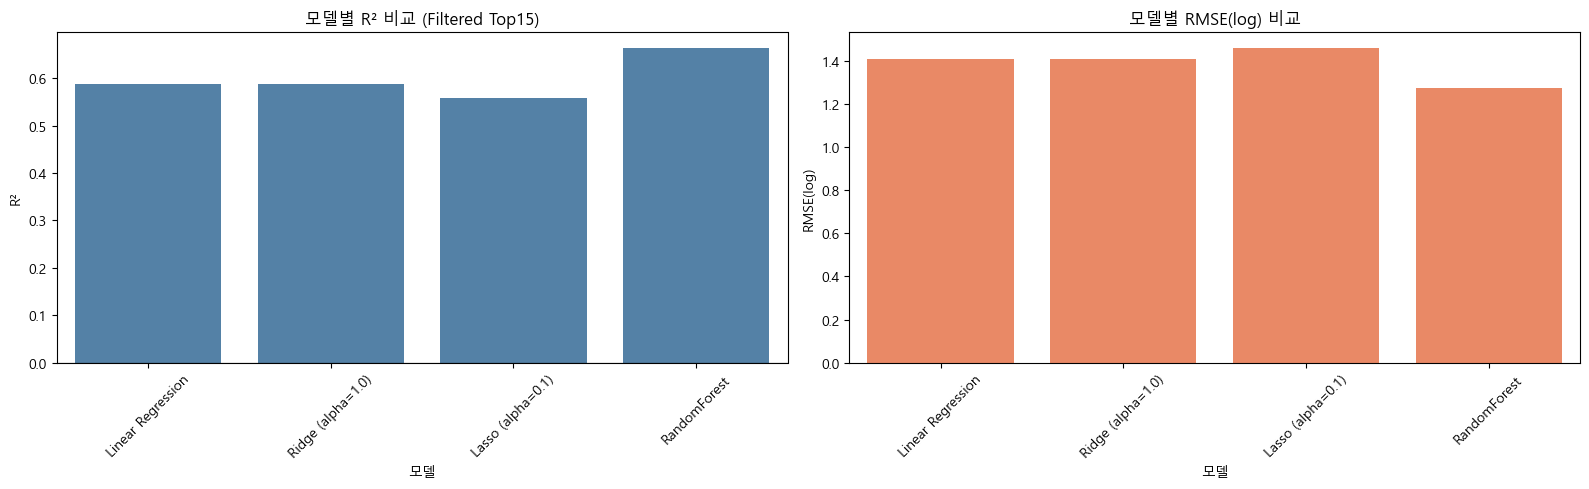

,모델,R²,RMSE(log),MAE(실제관객수_만명)
3,RandomForest,0.547733,1.370505,31.331765
2,Lasso,0.523343,1.406975,41.306030
0,Linear Regression,0.523337,1.406984,41.309138
1,Ridge,0.523306,1.407030,41.156745


In [13]:
df_plot = pd.DataFrame(
    [
        {
            "모델": name,
            "R²": result["R²"],
            "RMSE(log)": result["RMSE(log)"],
            "MAE(실제관객수_만명)": result["MAE(실제)"] / 1e4,
        }
        for name, result in reg_results.items()
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R² 비교: 높을수록 좋음
sns.barplot(data=df_plot, x="모델", y="R²", ax=axes[0], color="steelblue")
axes[0].set_title("모델별 R² 비교 (Filtered Top15)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(0, color="black", linewidth=0.8)

# RMSE 비교: 낮을수록 좋음
sns.barplot(data=df_plot, x="모델", y="RMSE(log)", ax=axes[1], color="coral")
axes[1].set_title("모델별 RMSE(log) 비교")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_fig(f"10_regression_model_comparison_{VERSION}.png")
plt.show()

df_plot.sort_values("R²", ascending=False)


---
## 13. 결과 요약

보고서나 디스코드에 붙여넣을 때는 아래 출력값을 사용하면 됩니다.


In [14]:
print("=" * 60)
print(f"결과 요약: 01_eda_baseline_{VERSION}.ipynb")
print("=" * 60)

print("\n[데이터 개요]")
print(f"  - 사용 버전  : feature_table_{VERSION}.csv")
print(f"  - 전체 샘플  : {len(df)}편")
print(f"  - 피처 수    : {len(FEATURE_COLS)}개 (수치형 {len(NUM_COLS)} + 범주형 {len(CAT_COLS)})")
print(f"  - 회귀 train/test : {len(X_train_reg)} / {len(X_test_reg)}")

print("\n[회귀 결과 — 타겟: log_audience]")
for name, result in reg_results.items():
    print(f'  - {name:<22} R²={result["R²"]:.4f} / MAE(실제)={result["MAE(실제)"]/1e4:.1f}만명')

print("\n[주요 EDA 인사이트]")
if "genre" in df.columns:
    best_genre = df.groupby("genre")["total_audience"].mean().idxmax()
    print(f"  - 평균 관객수 1위 장르: {best_genre}")

if "is_korean" in df.columns:
    print(f'  - 한국 영화 평균 관객수: {df[df["is_korean"] == 1]["total_audience"].mean()/1e4:.1f}만명')
    print(f'  - 외국 영화 평균 관객수: {df[df["is_korean"] == 0]["total_audience"].mean()/1e4:.1f}만명')

print(f"  - log_audience와 가장 상관 높은 피처: {corr_target.abs().idxmax()}")

print("=" * 60)


결과 요약: 01_eda_baseline_v3.ipynb

[데이터 개요]
  - 사용 버전  : feature_table_v3.csv
  - 전체 샘플  : 2489편
  - 피처 수    : 15개 (수치형 15 + 범주형 0)
  - 회귀 train/test : 1991 / 498

[회귀 결과 — 타겟: log_audience]
  - Linear Regression      R²=0.5233 / MAE(실제)=41.3만명
  - Ridge                  R²=0.5233 / MAE(실제)=41.2만명
  - Lasso                  R²=0.5233 / MAE(실제)=41.3만명
  - RandomForest           R²=0.5477 / MAE(실제)=31.3만명

[주요 EDA 인사이트]
  - 평균 관객수 1위 장르: 사극
  - 한국 영화 평균 관객수: 84.2만명
  - 외국 영화 평균 관객수: 41.7만명
  - log_audience와 가장 상관 높은 피처: relative_search_share
